In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [146]:
df = pd.read_csv('C:\\day-17\\knn_regression_dataset.csv')

In [147]:
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [148]:
df

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404
...,...,...,...,...,...,...,...
995,60,NaN,272663.033166,502.604714,Chennai,Salaried,155285.942941
996,64,36687.617333,133069.710014,730.751324,Bangalore,Self-Employed,65076.404995
997,62,43438.125495,234645.931152,747.044458,Hyderabad,Unemployed,126006.462108
998,35,60835.720367,169706.958962,628.847359,Bangalore,Unemployed,118101.789665


In [149]:
#split city column into 4 columns based on city names chennai, hyderabad, bangalore, mumbai

df['chennai'] = df['city'].apply(lambda x: 1 if x == 'Chennai' else 0)
df['hyderabad'] = df['city'].apply(lambda x: 1 if x == 'Hyderabad' else 0)
df['bangalore'] = df['city'].apply(lambda x: 1 if x == 'Bangalore' else 0)
df['mumbai'] = df['city'].apply(lambda x: 1 if x == 'Mumbai' else 0)

In [150]:
df.drop('city',axis=1,inplace=True)

In [151]:
df.head()

,age,income,loan_amount,credit_score,employment_type,target,chennai,hyderabad,bangalore,mumbai
0,56,25903.305196,286348.192562,789.476075,Salaried,158793.631698,1,0,0,0
1,69,53051.954538,180018.190719,596.334039,Salaried,115596.093965,1,0,0,0
2,46,38654.738821,211234.236288,611.531000,Salaried,127231.057638,1,0,0,0
3,32,28666.194356,246629.541594,710.171152,Unemployed,145102.187078,1,0,0,0
4,60,40301.406736,129081.713353,622.900855,Unemployed,110623.128404,0,1,0,0


In [152]:
#split employment type column into 3 columns based on employment type salaried and unemployed self employed

df['salaried'] = df['employment_type'].apply(lambda x: 1 if x == 'Salaried' else 0)
df['unemployed'] = df['employment_type'].apply(lambda x: 1 if x == 'Unemployed' else 0)
df['self_employed'] = df['employment_type'].apply(lambda x: 1 if x == 'Self Employed' else 0)
df.drop('employment_type',axis=1,inplace=True)
df.head()

,age,income,loan_amount,credit_score,target,chennai,hyderabad,bangalore,mumbai,salaried,unemployed,self_employed
0,56,25903.305196,286348.192562,789.476075,158793.631698,1,0,0,0,1,0,0
1,69,53051.954538,180018.190719,596.334039,115596.093965,1,0,0,0,1,0,0
2,46,38654.738821,211234.236288,611.531000,127231.057638,1,0,0,0,1,0,0
3,32,28666.194356,246629.541594,710.171152,145102.187078,1,0,0,0,0,1,0
4,60,40301.406736,129081.713353,622.900855,110623.128404,0,1,0,0,0,1,0


In [153]:
#check mean median for income loan amount and credit score

print("Mean of income column", df['income'].mean())
print("Median of income column", df['income'].median())
print("Mean of loan amount column", df['loan_amount'].mean())   
print("Median of loan amount column", df['loan_amount'].median())
print("Mean of credit score column", df['credit_score'].mean())
print("Median of credit score column", df['credit_score'].median())

Mean of income column 52924.86051488685
Median of income column 51119.92518950612
Mean of loan amount column 204508.53187200893
Median of loan amount column 200190.69362932903
Mean of credit score column 649.4222231628565
Median of credit score column 649.9780429171758


In [154]:
#handle missing values using median

df['income'] = df['income'].fillna(df['income'].median())
df['loan_amount'] = df['loan_amount'].fillna(df['loan_amount'].median())
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())

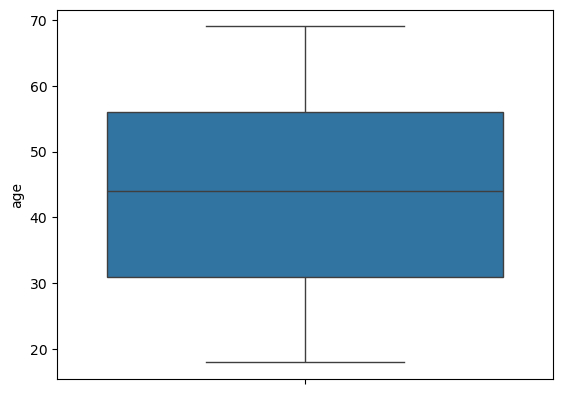

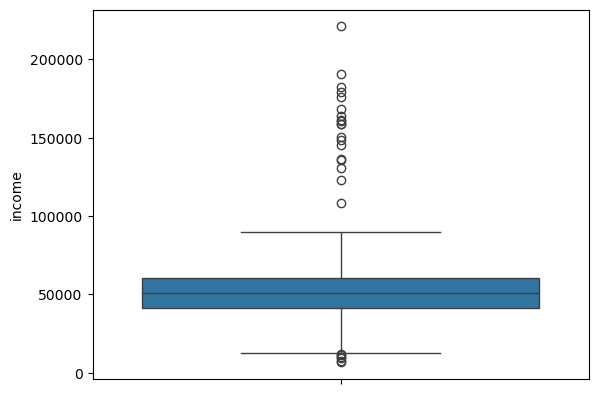

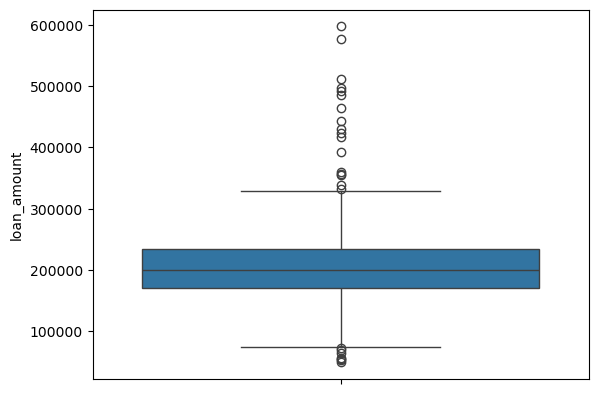

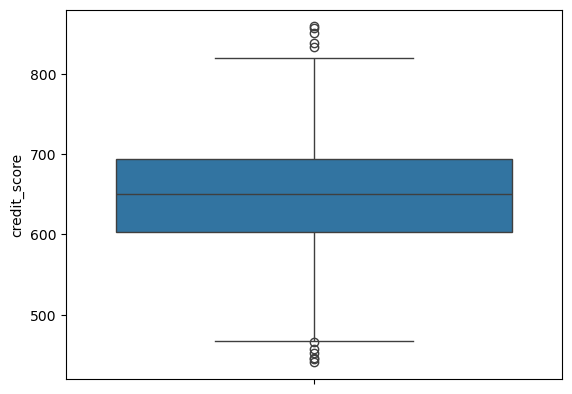

In [155]:
#check outliers

sns.boxplot(df['age'])
plt.show()

sns.boxplot(df['income'])
plt.show()

sns.boxplot(df['loan_amount'])
plt.show()

sns.boxplot(df['credit_score'])
plt.show()

In [156]:
#handled the outlier length of each column

#credit score column
Q1 = df['credit_score'].quantile(0.25)
Q3 = df['credit_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)
df = df[(df['credit_score'] > lower_bound) & (df['credit_score'] < upper_bound)]
print("No. of outliers in credit score column", df['credit_score'].isnull().sum())

#loan amount column
Q1 = df['loan_amount'].quantile(0.25)
Q3 = df['loan_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)
df = df[(df['loan_amount'] > lower_bound) & (df['loan_amount'] < upper_bound)]
print("No. of outliers in loan amount column", df['loan_amount'].isnull().sum())


#income column
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)
df = df[(df['income'] > lower_bound) & (df['income'] < upper_bound)]
print("No. of outliers in income column", df['income'].isnull().sum())

No. of outliers in credit score column 0
No. of outliers in loan amount column 0
No. of outliers in income column 0


In [157]:
df.isnull().sum()

age              0
income           0
loan_amount      0
credit_score     0
target           0
chennai          0
hyderabad        0
bangalore        0
mumbai           0
salaried         0
unemployed       0
self_employed    0
dtype: int64

In [158]:
#minmax scaler

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['loan_amount'] = scaler.fit_transform(df[['loan_amount']])
df['credit_score'] = scaler.fit_transform(df[['credit_score']])
df['income'] = scaler.fit_transform(df[['income']])

In [176]:
#check skewness after minmax scaler

print("Skewness of loan amount column", skew(df['loan_amount']))
print("Skewness of credit score column", skew(df['credit_score']))


Skewness of loan amount column 0.052272862398380505
Skewness of credit score column -0.04496296547236644


In [ ]:
from scipy.stats import skew
skewness=df['target'].skew()
print("Skewness of the target column:",skewness)

Skewness of the target column: 0.0902373552820234


In [161]:
# check the normal , postive skewness and negative skewness features
skewness = df.select_dtypes(include=[np.number]).apply(skew)
normal_skewed_features = skewness[skewness == 0].index.tolist()
positive_skewed_features = skewness[skewness > 0].index.tolist()
negative_skewed_features = skewness[skewness < 0].index.tolist()
 
print("Normal skewed features: ", normal_skewed_features)
print("Positive skewed features: ", positive_skewed_features)
print("Negative skewed features: ", negative_skewed_features)

Normal skewed features:  []
Positive skewed features:  ['income', 'loan_amount', 'target', 'chennai', 'hyderabad', 'bangalore', 'mumbai', 'salaried', 'unemployed']
Negative skewed features:  ['age', 'credit_score']


In [162]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['credit_score'] = scaler.fit_transform(df['credit_score'].values.reshape(-1, 1))
#or df['credit_score'] = scaler.fit_transform(df[['credit_score']])

In [163]:
#divide the data into features and target variable
X=df.drop('target',axis=1)
y=df['target']

In [ ]:
#divide the data into training and testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [165]:
#model1:KNN
from sklearn.neighbors import KNeighborsRegressor
#load the model
knn=KNeighborsRegressor(n_neighbors=5)
#fit the model
knn.fit(X_train,y_train)
#predict
y_pred=knn.predict(X_test)
#check accuracy
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("MSE:",mse)
print("MAE:",mae)
print("R2:",r2)



MSE: 729318319.6294805
MAE: 21892.23815501523
R2: -0.20299538486170876


In [166]:
# make the elbow plot to find the optimal value of k
mse_values = []
k_values = range(1, 21)
 
for k in k_values:
    # load the model
    knn_regressor = KNeighborsRegressor(n_neighbors=k)
 
    # fit the model on the training data
    knn_regressor.fit(X_train, y_train)
 
    #predict the target variable on the testing data
    y_pred = knn_regressor.predict(X_test)
 
    #find the MSE
    mse = mean_squared_error(y_test, y_pred)
 
    #append the MSE value to the list
    mse_values.append(mse)
 

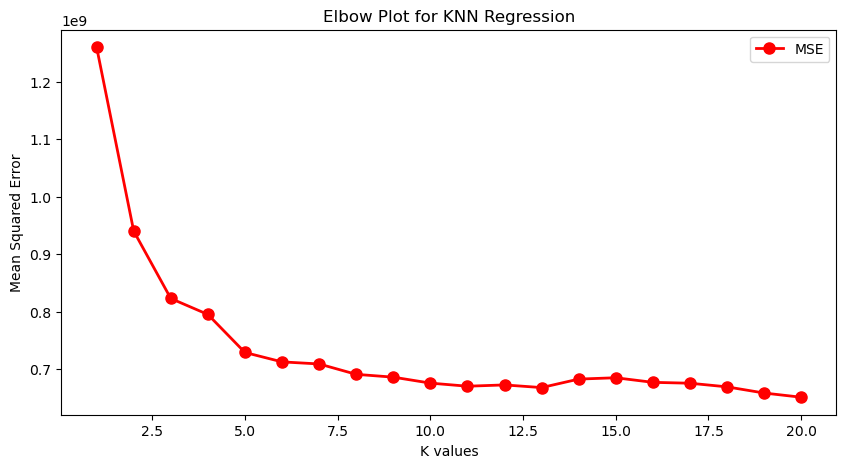

In [168]:
# plot the elbow plot
plt.figure(figsize=(10,5))
plt.plot(k_values, mse_values, marker='o',color='red',linewidth=2,markersize=8,label='MSE',)
plt.title("Elbow Plot for KNN Regression")
plt.xlabel("K values")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()

In [169]:
#model2 linear regression
from sklearn.linear_model import LinearRegression

#load the model
lr = LinearRegression()

#fit the model
lr.fit(X_train, y_train)

#predict the target variable
y_pred_lr = lr.predict(X_test)

#evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression - Mean Squared Error:", mse_lr)
print("Linear Regression - R2 Score:", r2_lr)

Linear Regression - Mean Squared Error: 108969477.06751013
Linear Regression - R2 Score: 0.8202571161662211


In [170]:
#model3 decision tree
from sklearn.tree import DecisionTreeRegressor

#load the model
dt = DecisionTreeRegressor()

#fit the model
dt.fit(X_train, y_train)

#predict the target variable
y_pred_dt = dt.predict(X_test)

#evaluate the model 
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print("Decision Tree - Mean Squared Error:", mse_dt)
print("Decision Tree - R2 Score:", r2_dt)

Decision Tree - Mean Squared Error: 239328989.0113176
Decision Tree - R2 Score: 0.6052318151140053


In [175]:
#find the train accuracy and test accuracy for all the models
print("KNN Regression - Train Accuracy:", knn.score(X_train, y_train))
print("KNN Regression - Test Accuracy:", knn.score(X_test, y_test))

KNN Regression - Train Accuracy: 0.30039469578803735
KNN Regression - Test Accuracy: -0.20299538486170876


In [173]:
print("Linear Regression - Train Accuracy:", lr.score(X_train, y_train))
print("Linear Regression - Test Accuracy:", lr.score(X_test, y_test))

Linear Regression - Train Accuracy: 0.8361875717406979
Linear Regression - Test Accuracy: 0.8202571161662211


In [174]:
print("Decision Tree - Train Accuracy:", dt.score(X_train, y_train))
print("Decision Tree - Test Accuracy:", dt.score(X_test, y_test))

Decision Tree - Train Accuracy: 1.0
Decision Tree - Test Accuracy: 0.6052318151140053
